In [1]:
import sys
sys.path.append("src/")

from pathlib import Path
import tqdm 
import random
import math
import time
from concurrent.futures import ThreadPoolExecutor
import threading
import ipaddress

from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

from proxyrecord import IpRecord
from utils import filecache

In [2]:
INPUT_FILE_PROXIES_BRIGHTDATA_SELFHOSTED = Path("data/prod-brightdata.json")
INPUT_FILE_PROXIES_BRIGHTDATA_IFCONFIG = Path("data/prod-withifconfig-brightdata.json")
INPUT_FILE_PROXIES_DECODO_SELFHOSTED = Path("data/prod-decodo.json")
INPUT_FILE_PROXIES_DECODO_IFCONFIG = Path("data/prod-withifconfig-decodo.json")

data_and_labels = [
    [INPUT_FILE_PROXIES_BRIGHTDATA_SELFHOSTED, "Brightdata to selfhosted infrastructure"],
    [INPUT_FILE_PROXIES_BRIGHTDATA_IFCONFIG, "Brightdata to ifconfig infrastructure"],
    [INPUT_FILE_PROXIES_DECODO_SELFHOSTED, "Decodo to selfhosted infrastructure"],
    [INPUT_FILE_PROXIES_DECODO_IFCONFIG, "Decodo to ifconfig infrastructure"]
]

for item in data_and_labels:
    [data, label] = item
    results = dict()
    data_from_disk = filecache.read_list_from_file(data, IpRecord)
    
    for i in data_from_disk:
        # assert i.abuse, f"{i}, {label}"
        results[i.ip] = i

    item.insert(0, results)

print("\n".join([f"Dataset {x[1]} has {len(x[0])} entries" for x in data_and_labels]))

Dataset data/prod-brightdata.json has 18 entries
Dataset data/prod-withifconfig-brightdata.json has 2752 entries
Dataset data/prod-decodo.json has 744 entries
Dataset data/prod-withifconfig-decodo.json has 579 entries


In [3]:
def histogram_abuse_on_ax(iprecords: dict, ax: plt.Axes, title: str) -> None:
    data = [iprecords[ip].abuse['amount'] for ip in iprecords]

    if not data:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        return

    min_val = min(data)
    max_val = max(data)
    bins = list(range(min_val, max_val + 2))
    centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]
    xticks = list(range(min_val, max_val + 1))

    counts, _, _ = ax.hist(
        data,
        bins=bins,
        edgecolor='black',
        color='#4C72B0',
        rwidth=0.9,
        density=True
    )

    max_ticks = 15
    if len(xticks) > max_ticks:
        step = math.ceil(len(xticks) / max_ticks)
        tick_positions = centers[::step]
        tick_labels = xticks[::step]
    else:
        tick_positions = centers
        tick_labels = xticks

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')

    ax.set_xlabel('Amount of abuse tickets')
    ax.set_ylabel('Fraction of IPs')   # changed: normalized
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

def rdns_piechart_on_ax(iprecords: dict, ax: plt.Axes, title: str) -> None:
    graph = defaultdict(int)
    
    for ip in iprecords:
        item = iprecords[ip].rdns
        
        if not item or item == "<none>":
            graph["unknown"] += 1
            continue
        
        rest = item.split(".", 1)[1] if "." in item else item
        graph[rest] += 1
    
    if not graph:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        return

    total = sum(graph.values())
    threshold = 0.025  

    merged = {}
    other_count = 0

    for k, v in graph.items():
        if v / total < threshold:
            other_count += v
        else:
            merged[k] = v

    if other_count > 0:
        merged["other"] = other_count

    graph = merged

    labels = list(graph.keys())
    values = list(graph.values())
    total = sum(values)
    percentages = [v / total * 100 for v in values]

    ax.set_title(title, pad=25)
    wedges, _ = ax.pie(
        values,
        wedgeprops=dict(width=0.5),
        startangle=-40
    )
    
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")
    
    label_data = []
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        label_text = f"{labels[i]} ({percentages[i]:.1f}%)"
        label_data.append((ang, x, y, label_text))
    
    label_data.sort(key=lambda t: t[2])
    
    min_dy = 0.08
    radius = 1.1
    xs_text = []
    ys_text = []
    
    for ang, x, y, label in label_data:
        x_text = 1.25 * np.sign(x)
        y_text = radius * y
    
        if ys_text:
            dy = y_text - ys_text[-1]
            if abs(dy) < min_dy:
                y_text = ys_text[-1] + min_dy * np.sign(dy if dy != 0 else 1)
    
        xs_text.append(x_text)
        ys_text.append(y_text)
    
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
    
        ax.annotate(
            label,
            xy=(x, y),
            xytext=(x_text, y_text),
            horizontalalignment=horizontalalignment,
            **kw
        )

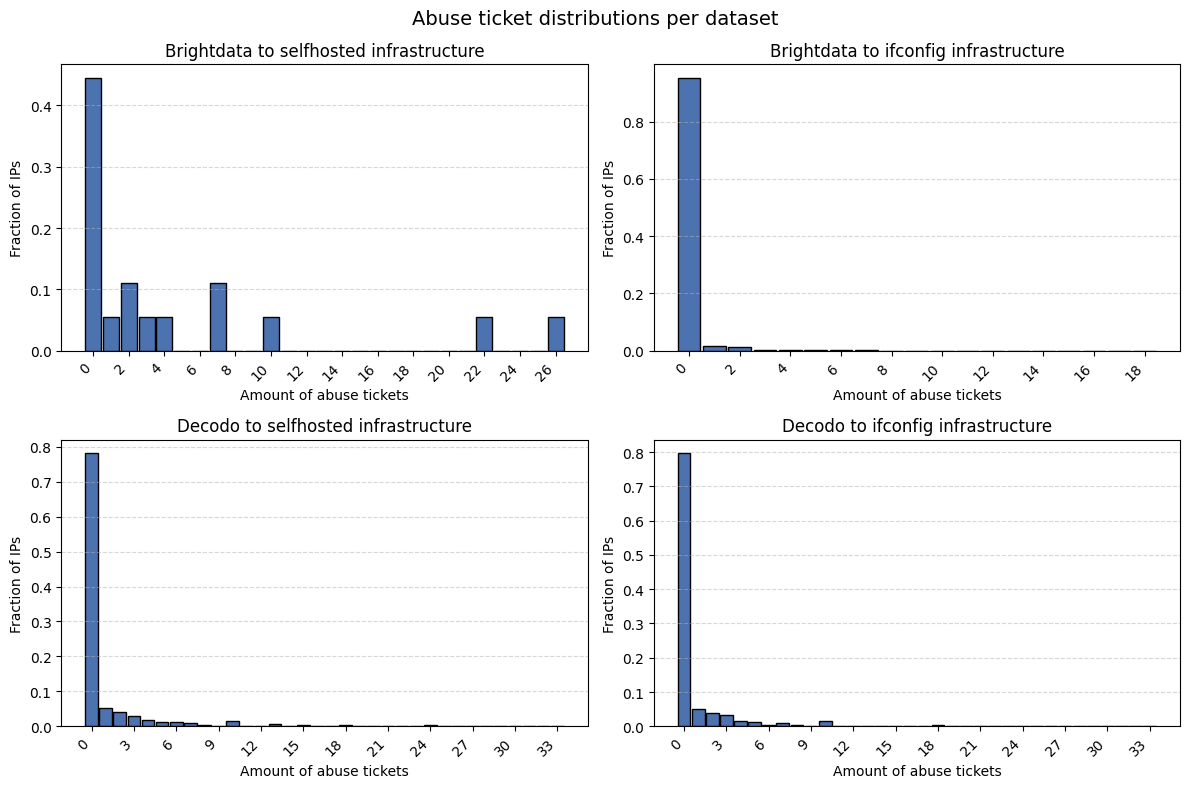

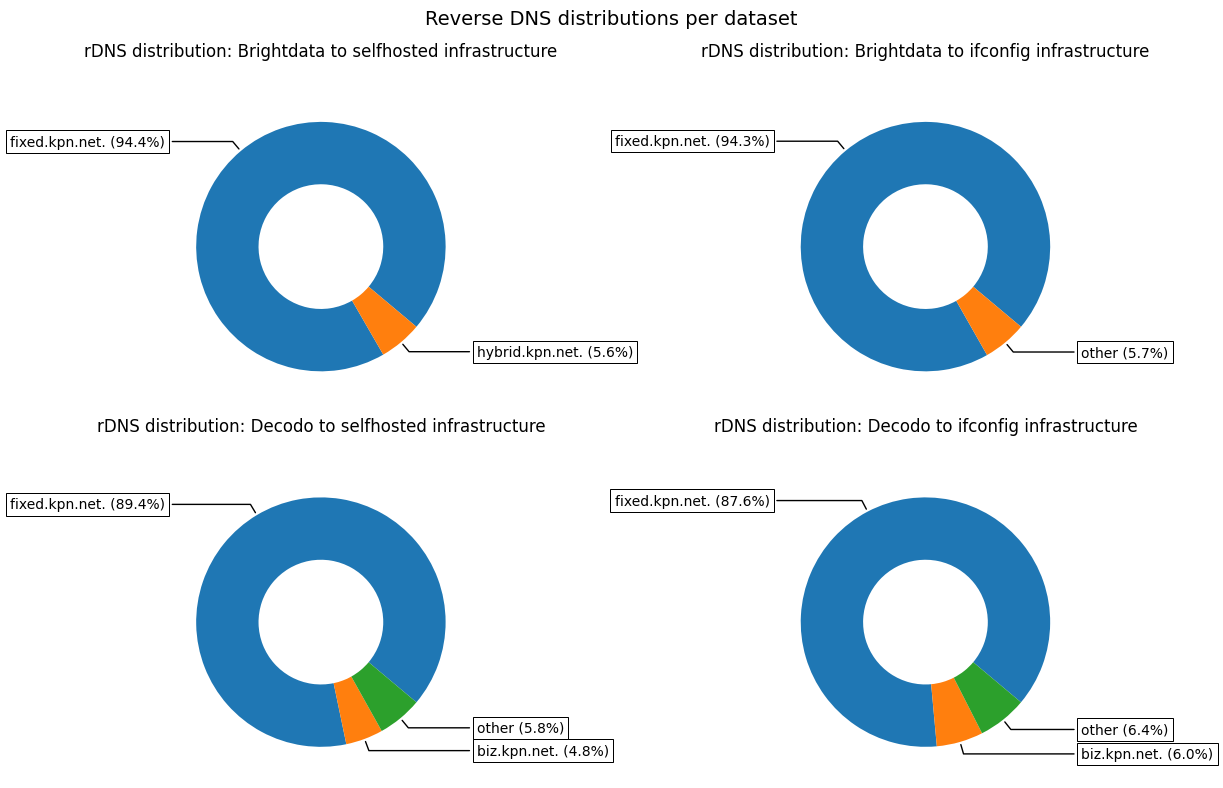


=== Dataset sizes ===
Dataset 'Brightdata to selfhosted infrastructure': 18 IPs
Dataset 'Brightdata to ifconfig infrastructure': 2752 IPs
Dataset 'Decodo to selfhosted infrastructure': 744 IPs
Dataset 'Decodo to ifconfig infrastructure': 579 IPs

Total IPs counted (sum over datasets): 4093
Total unique IPs across all datasets: 3571

=== Overlap in IPs between datasets ===
Overlap between 'Brightdata to selfhosted infrastructure' and 'Brightdata to ifconfig infrastructure': 0 IPs
Overlap between 'Brightdata to selfhosted infrastructure' and 'Decodo to selfhosted infrastructure': 2 IPs
Overlap between 'Brightdata to selfhosted infrastructure' and 'Decodo to ifconfig infrastructure': 1 IPs
Overlap between 'Brightdata to ifconfig infrastructure' and 'Decodo to selfhosted infrastructure': 24 IPs
Overlap between 'Brightdata to ifconfig infrastructure' and 'Decodo to ifconfig infrastructure': 22 IPs
Overlap between 'Decodo to selfhosted infrastructure' and 'Decodo to ifconfig infrastructure'

In [5]:
n = len(data_and_labels)

fig_hist, axes_hist = plt.subplots(2, 2, figsize=(12, 8))
axes_hist = axes_hist.flatten()

for idx, item in enumerate(data_and_labels):
    results_dict = item[0]
    label = item[2]
    histogram_abuse_on_ax(results_dict, axes_hist[idx], label)

fig_hist.suptitle("Abuse ticket distributions per dataset", fontsize=14)
plt.tight_layout()
fig_hist.savefig("output/histograms_abuse_per_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

fig_pie, axes_pie = plt.subplots(2, 2, figsize=(12, 8))
axes_pie = axes_pie.flatten()

for idx, item in enumerate(data_and_labels):
    results_dict = item[0]
    label = item[2]
    title = f"rDNS distribution: {label}"
    rdns_piechart_on_ax(results_dict, axes_pie[idx], title)

fig_pie.suptitle("Reverse DNS distributions per dataset", fontsize=14)
plt.tight_layout()
fig_pie.savefig("output/piecharts_rdns_per_dataset.png", dpi=300, bbox_inches="tight")

plt.show()

n = len(data_and_labels)

ip_sets = []
labels = []
for item in data_and_labels:
    results_dict = item[0]
    label = item[2]
    ip_sets.append(set(results_dict.keys()))
    labels.append(label)

sizes = [len(s) for s in ip_sets]
total_ips_counted = sum(sizes)
total_unique_ips = len(set().union(*ip_sets))

print("\n=== Dataset sizes ===")
for label, size in zip(labels, sizes):
    print(f"Dataset '{label}': {size} IPs")

print(f"\nTotal IPs counted (sum over datasets): {total_ips_counted}")
print(f"Total unique IPs across all datasets: {total_unique_ips}")

print("\n=== Overlap in IPs between datasets ===")
for i in range(n):
    for j in range(i + 1, n):
        overlap = ip_sets[i] & ip_sets[j]
        print(f"Overlap between '{labels[i]}' and '{labels[j]}': {len(overlap)} IPs")